# Polaris Support Tickets — EDA

**~24,000 synthetic support tickets** for *Polaris*, a fictional multichannel
analytics SaaS. Coherent ground-truth triage labels + a noisy intake category, over
**Jan 2024 → Jun 2026**, with a **temporal event layer** (outages + launches).

This notebook verifies the dataset's *temporal signature* — the clustering and
seasonality a real support queue shows — which makes it usable for triage,
RAG-deflection **and** time-series (forecasting / anomaly detection).

Full pipeline & modeling: https://github.com/VladislavMarinovich/saas-support-rag-triage

> Synthetic data, generated on a real pipeline. No real users, no PII.

In [1]:
import glob, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
ACCENT, BASE_C, EVT_C = "#2E5A87", "#9db8d2", "#d9534f"


def aligned_category(topic, type_):
    """The picklist bucket a correctly self-tagging user would pick."""
    if type_ == "how_to": return "how_to_question"
    if type_ == "security": return "security_concern"
    if type_ in ("bug", "outage"): return "bug_something_broken"
    if topic == "billing" or type_ == "billing": return "account_billing"
    if topic == "connectors": return "connectors_integrations"
    if topic in ("dashboards", "reports", "northstar"): return "dashboards_reports"
    if topic == "attribution": return "attribution"
    if topic == "alerts": return "alerts"
    if topic == "users_workspace": return "users_access"
    return "other"


# Kaggle mounts the dataset under /kaggle/input; fall back to local paths for dev.
cands = (glob.glob("/kaggle/input/*/polaris_tickets_v2.parquet")
         + glob.glob("/kaggle/input/*/polaris_tickets_v2.csv")
         + ["../data/polaris_tickets_v2.parquet", "data/polaris_tickets_v2.parquet",
            "../data/tickets_v2.jsonl", "data/tickets_v2.jsonl"])
path = next((p for p in cands if p and os.path.exists(p)), None)
if path is None:  # last resort: search the mounted input tree
    path = glob.glob("/kaggle/input/**/polaris_tickets_v2.*", recursive=True)[0]
if path.endswith(".jsonl"):
    df = pd.read_json(path, lines=True)
elif path.endswith(".csv"):
    df = pd.read_csv(path)
else:
    df = pd.read_parquet(path)
print("loaded from:", path)

df["created_at"] = pd.to_datetime(df["created_at"])
df["month"] = df["created_at"].dt.to_period("M").dt.to_timestamp()
df["is_event"] = df["event_id"].notna()
len(df), df["created_at"].min().date(), df["created_at"].max().date()

loaded from: ../data/polaris_tickets_v2.parquet


(23994, datetime.date(2024, 1, 1), datetime.date(2026, 6, 30))

## The dataset at a glance

In [2]:
n = len(df); ev = int(df.is_event.sum())
print(f"tickets            : {n:,}")
print(f"span               : {df.created_at.min().date()} -> {df.created_at.max().date()}")
print(f"event-driven       : {ev:,} ({ev/n*100:.1f}%)   baseline: {n-ev:,} ({(n-ev)/n*100:.1f}%)")
print(f"unique labels      : topic={df.topic.nunique()} type={df.type.nunique()} "
      f"priority={df.priority.nunique()} routing={df.routing.nunique()} sentiment={df.sentiment.nunique()}")
print("\nby year:")
print(df.groupby(df.created_at.dt.year).size().to_string())

tickets            : 23,994
span               : 2024-01-01 -> 2026-06-30
event-driven       : 6,000 (25.0%)   baseline: 17,994 (75.0%)
unique labels      : topic=8 type=8 priority=4 routing=5 sentiment=6

by year:
created_at
2024     6017
2025    11979
2026     5998


### Event catalog

Every event in the layer, with its type, window and ticket count.

In [3]:
cat = (df[df.is_event].groupby(["event_id", "event_type"])
       .agg(tickets=("ticket_id", "size"), first=("created_at", "min"), last=("created_at", "max"))
       .reset_index())
cat["first"] = cat["first"].dt.date; cat["last"] = cat["last"].dt.date
cat.sort_values("first").reset_index(drop=True)

,event_id,event_type,tickets,first,last
0,launch_constant_contact_connector,launch,450,2024-02-18,2024-08-10
1,outage_ga4_sync_2024q1,outage,200,2024-02-20,2024-02-24
2,outage_dashboards_2024q3,outage,200,2024-07-09,2024-07-12
3,launch_klaviyo_connector,launch,450,2024-07-25,2025-01-05
4,outage_hubspot_sync_2024q4,outage,200,2024-11-05,2024-11-09
5,launch_salesforce_connector,launch,700,2024-12-10,2025-06-01
6,launch_tiktok_connector,launch,900,2025-02-18,2025-08-10
7,outage_dashboards_2025q1,outage,400,2025-03-12,2025-03-15
8,launch_zoho_connector,launch,700,2025-06-21,2025-12-14
9,outage_ga4_sync_2025q3,outage,400,2025-08-19,2025-08-23


### Per-year summary

In [4]:
yr = (df.assign(year=df.created_at.dt.year).groupby("year")
      .agg(tickets=("ticket_id", "size"), event_driven=("is_event", "sum")))
yr["baseline"] = yr["tickets"] - yr["event_driven"]
yr["event_%"] = (yr["event_driven"] / yr["tickets"] * 100).round(1)
yr

,tickets,event_driven,baseline,event_%
year,,,,
2024,6017,1517,4500,25.2
2025,11979,3483,8496,29.1
2026,5998,1000,4998,16.7


### Metadata mix (channel · plan · role)

In [5]:
meta = {c: (df[c].value_counts() / len(df) * 100).round(1)
        for c in ["channel", "plan", "user_role"]}
pd.DataFrame(meta).rename_axis("value").fillna("")

,channel,plan,user_role
value,,,
admin,,,40.1
analyst,,,36.5
chat,35.0,,
email,49.9,,
enterprise,,15.0,
growth,,35.0,
in_app,15.1,,
starter,,50.0,
viewer,,,23.4


## 1. The temporal signature — the point of the dataset

Monthly volume, split into the steady baseline and the event-driven tickets on top.

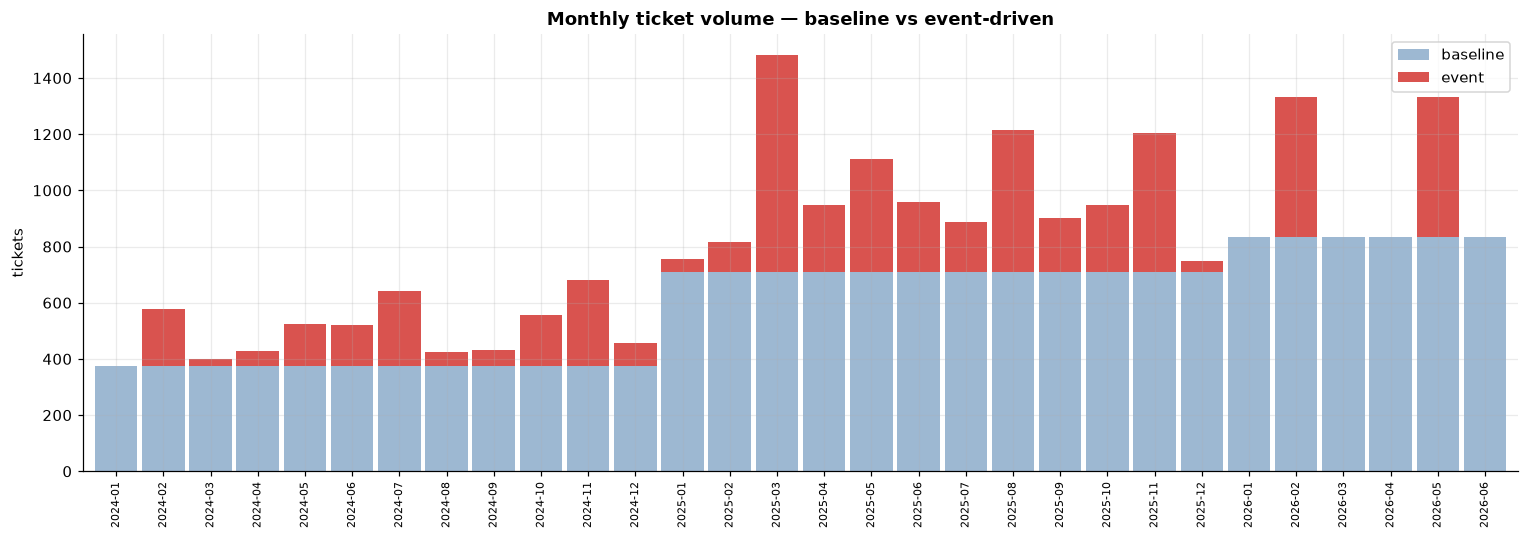

In [6]:
piv = (df.groupby(["month", "is_event"]).size()
         .unstack(fill_value=0).rename(columns={False: "baseline", True: "event"}))
piv.index = piv.index.strftime("%Y-%m")
ax = piv[["baseline", "event"]].plot(kind="bar", stacked=True, figsize=(14, 5),
                                     color=[BASE_C, EVT_C], width=0.9)
ax.set_title("Monthly ticket volume — baseline vs event-driven", fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("tickets")
ax.tick_params(axis="x", labelrotation=90, labelsize=7); ax.legend(title="")
plt.tight_layout(); plt.show()

**Read it:** the baseline grows ~2x from 2024 to 2025 as the company scales.
Red spikes are **outages** (a connector/dashboards break → a burst in days); wider
red build-ups are **launch waves** (a new connector ships → weeks of how-to
questions). That clustering is what a forecasting/anomaly model needs.

## 2. The launch arc — requests that vanish on launch day

Connector feature-requests per month, with each launch date marked.

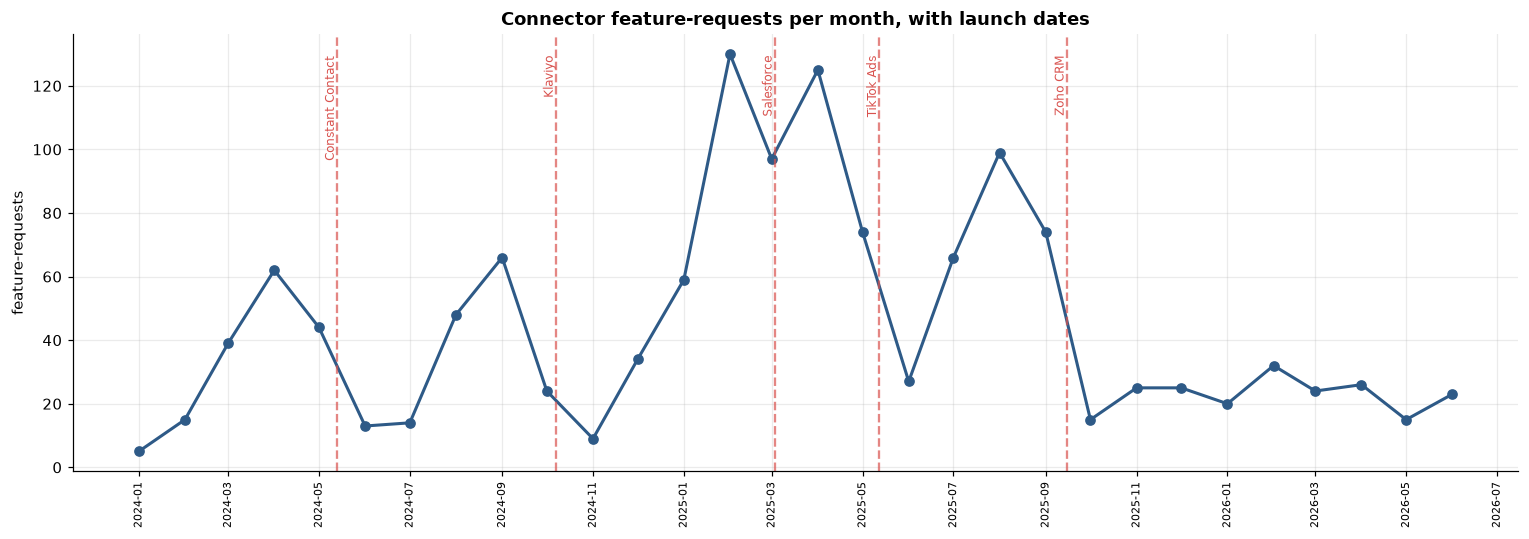

In [7]:
fr = df[(df.type == "feature_request") & (df.topic == "connectors")]
m = fr.groupby("month").size()
launches = {"Constant Contact": "2024-05-13", "Klaviyo": "2024-10-07",
            "Salesforce": "2025-03-03", "TikTok Ads": "2025-05-12", "Zoho CRM": "2025-09-15"}
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(m.index, m.values, marker="o", color=ACCENT, lw=2)
for name, d in launches.items():
    ts = pd.Timestamp(d); ax.axvline(ts, color=EVT_C, ls="--", alpha=0.7)
    ax.text(ts, ax.get_ylim()[1]*0.95, name, rotation=90, va="top", ha="right",
            fontsize=8, color=EVT_C)
ax.set_title("Connector feature-requests per month, with launch dates", fontweight="bold")
ax.set_ylabel("feature-requests"); ax.set_xlabel("")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=90, fontsize=7); plt.tight_layout(); plt.show()

**Read it:** the requests build up *toward* each launch and drop right after —
demand for a connector is answered by shipping it. A clean temporal signal that
pivots on a known date.

## 3. Label distributions — the ML targets

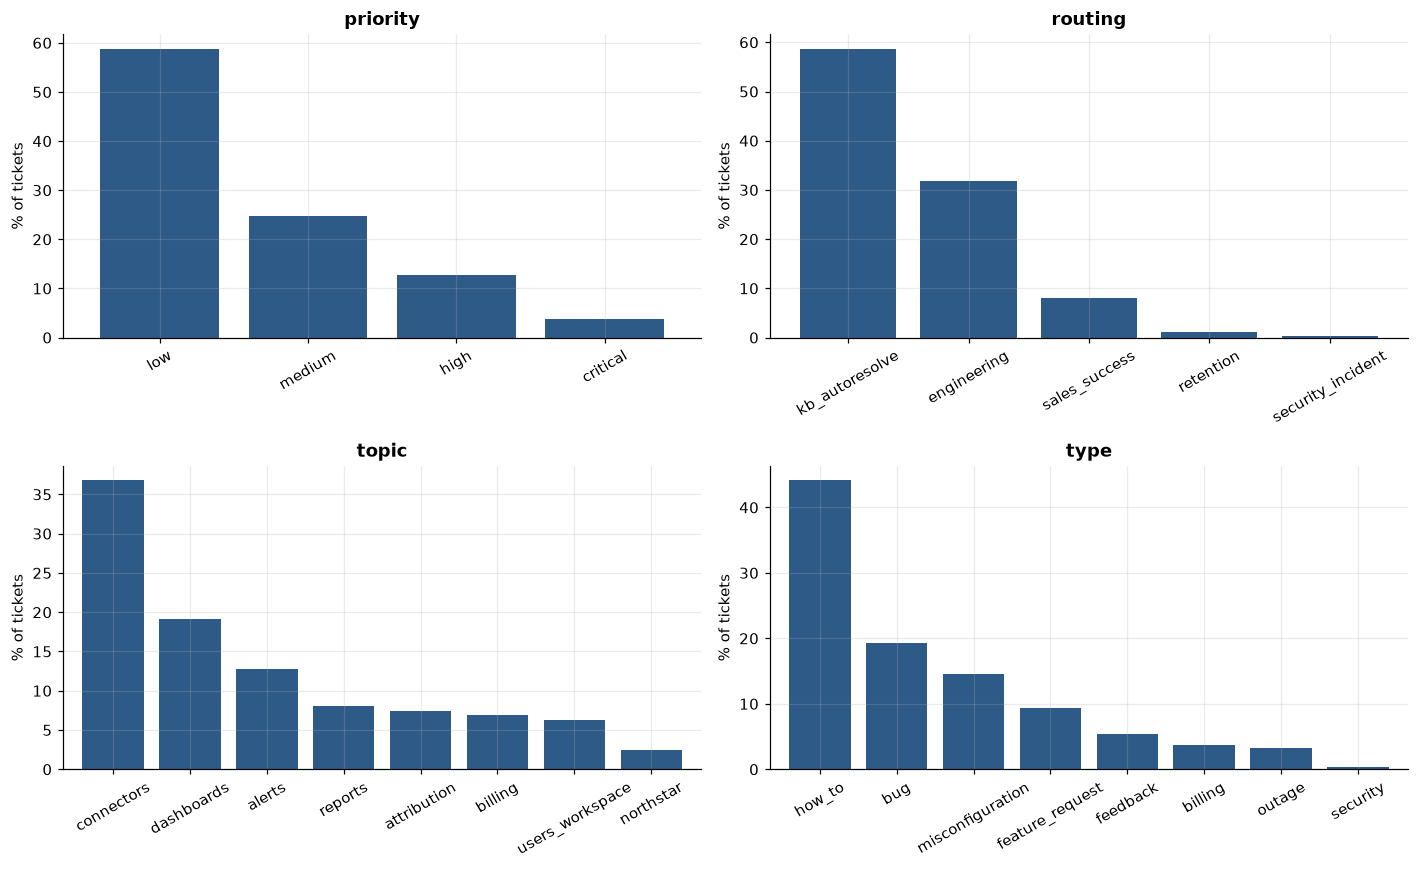

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, order) in zip(axes.ravel(),
        [("priority", ["low","medium","high","critical"]), ("routing", None),
         ("topic", None), ("type", None)]):
    vc = df[col].value_counts()
    if order: vc = vc.reindex(order)
    (vc/len(df)*100).plot(kind="bar", ax=ax, color=ACCENT, width=0.8)
    ax.set_title(col, fontweight="bold"); ax.set_ylabel("% of tickets")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Read it:** **priority** follows a realistic long tail; **routing** is
dominated by `kb_autoresolve` (the deflection opportunity); **topic**/**type** stay
spread across the product so no class trivially dominates.

### Exact frequencies — the numbers behind the bars

In [9]:
def freq_table(col, order=None):
    vc = df[col].value_counts()
    if order: vc = vc.reindex(order)
    return pd.DataFrame({"count": vc, "pct_%": (vc/len(df)*100).round(1)})
pd.concat({c: freq_table(c) for c in ["topic", "type", "routing"]}, names=["field", "value"])

count  pct_%
field   value                          
topic   connectors          8827   36.8
        dashboards          4600   19.2
        alerts              3065   12.8
        reports             1940    8.1
        attribution         1777    7.4
        billing             1666    6.9
        users_workspace     1515    6.3
        northstar            604    2.5
type    how_to             10591   44.1
        bug                 4644   19.4
        misconfiguration    3498   14.6
        feature_request     2237    9.3
        feedback            1288    5.4
        billing              895    3.7
        outage               764    3.2
        security              77    0.3
routing kb_autoresolve     14089   58.7
        engineering         7645   31.9
        sales_success       1924    8.0
        retention            259    1.1
        security_incident     77    0.3

In [10]:
freq_table("priority", ["low", "medium", "high", "critical"])

,count,pct_%
priority,,
low,14116,58.8
medium,5935,24.7
high,3051,12.7
critical,892,3.7


### Cross-tab: topic × type

In [11]:
pd.crosstab(df.topic, df.type, margins=True, margins_name="Total")

type,billing,bug,feature_request,feedback,how_to,misconfiguration,outage,security,Total
topic,,,,,,,,,
alerts,0,571,908,0,901,685,0,0,3065
attribution,0,0,0,0,859,918,0,0,1777
billing,895,0,0,0,771,0,0,0,1666
connectors,0,2031,1329,0,4614,853,0,0,8827
dashboards,0,1468,0,1288,1080,0,764,0,4600
northstar,0,51,0,0,553,0,0,0,604
reports,0,523,0,0,890,527,0,0,1940
users_workspace,0,0,0,0,923,515,0,77,1515
Total,895,4644,2237,1288,10591,3498,764,77,23994


### Cross-tab: routing × priority

In [12]:
ct = pd.crosstab(df.routing, df.priority, margins=True, margins_name="Total")
ct[["low", "medium", "high", "critical", "Total"]]

priority,low,medium,high,critical,Total
routing,,,,,
engineering,2237,2437,2156,815,7645
kb_autoresolve,10591,3498,0,0,14089
retention,0,0,259,0,259
sales_success,1288,0,636,0,1924
security_incident,0,0,0,77,77
Total,14116,5935,3051,892,23994


## 4. Sentiment — an operational prioritization signal

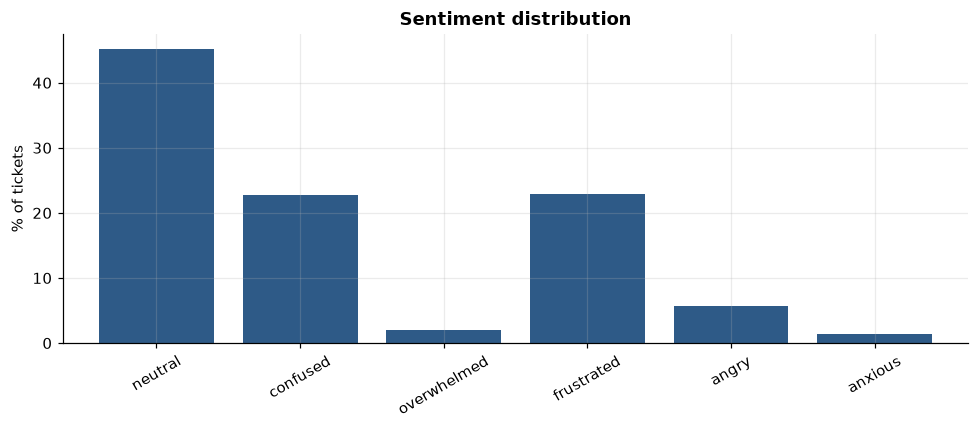

In [13]:
order = ["neutral", "confused", "overwhelmed", "frustrated", "angry", "anxious"]
vc = (df["sentiment"].value_counts().reindex(order) / len(df) * 100)
ax = vc.plot(kind="bar", figsize=(9, 4), color=ACCENT, width=0.8)
ax.set_title("Sentiment distribution", fontweight="bold")
ax.set_ylabel("% of tickets"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Read it:** sentiment is an **operational** signal (reach the angry/anxious
customer faster), not a claim about feelings — so the metric that matters is recall
on action-triggering emotions, not raw accuracy.

## 5. Intake noise — why a triage classifier earns its keep

`reported_category` is the customer's own dropdown pick; `aligned_category` is what
a correctly self-tagging user should have chosen. The gap is the headroom a model
recovers from the text.

In [14]:
df["aligned"] = [aligned_category(t, ty) for t, ty in zip(df.topic, df.type)]
df["intake_ok"] = df.reported_category == df.aligned
print(f"overall intake mismatch: {(~df.intake_ok).mean()*100:.1f}% of tickets pick a "
      f"category that disagrees with the true labels")

overall intake mismatch: 35.1% of tickets pick a category that disagrees with the true labels


Mismatch rate by true topic — where users mis-tag most:

In [15]:
g = df.groupby("topic")["intake_ok"]
noise = pd.DataFrame({"n": g.size(), "mismatch_%": ((1 - g.mean()) * 100).round(1)})
noise.sort_values("mismatch_%", ascending=False)

,n,mismatch_%
topic,,
reports,1940,37.8
attribution,1777,36.8
billing,1666,35.8
dashboards,4600,35.6
connectors,8827,34.5
users_workspace,1515,34.1
alerts,3065,33.9
northstar,604,32.8


**Read it:** ~a third of tickets arrive mis-categorized by the user. A model
that reads the *text* and predicts the true topic/type turns noisy intake into a
reliable routing signal — the concrete business value.

## 6. Event impact on severity

Priority mix inside event windows vs the baseline flow.

In [16]:
sev = pd.DataFrame({
    "baseline_%": (df[~df.is_event].priority.value_counts(normalize=True) * 100).round(1),
    "event_%": (df[df.is_event].priority.value_counts(normalize=True) * 100).round(1),
}).reindex(["low", "medium", "high", "critical"])
sev

,baseline_%,event_%
priority,,
low,60.7,53.3
medium,29.5,10.4
high,8.9,24.1
critical,0.9,12.1


**Read it:** event-driven tickets skew toward high/critical vs the calm
baseline — the severity spike a real incident produces. The baseline alone sits
near 60/30/9/1 (the design target); the global skew comes from the events.

## 7. Message length

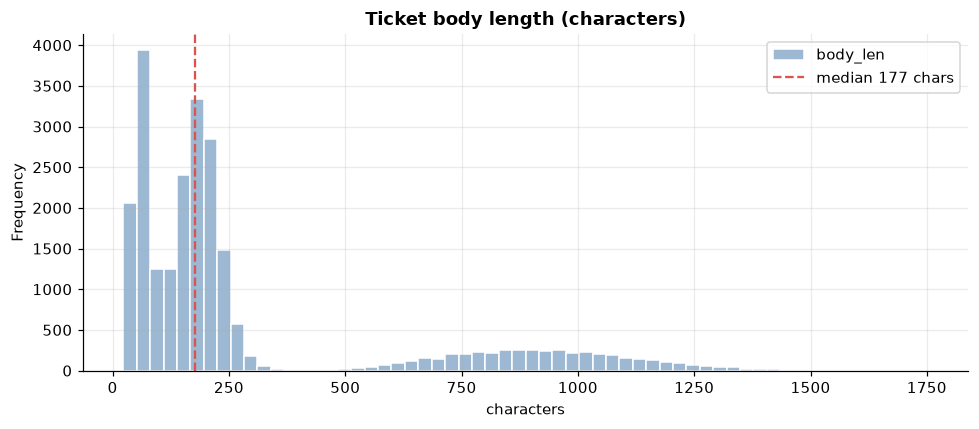

In [17]:
df["body_len"] = df["body"].fillna("").str.len()
ax = df["body_len"].plot(kind="hist", bins=60, figsize=(9, 4), color=BASE_C, edgecolor="white")
ax.axvline(df.body_len.median(), color=EVT_C, ls="--",
           label=f"median {int(df.body_len.median())} chars")
ax.set_title("Ticket body length (characters)", fontweight="bold")
ax.set_xlabel("characters"); ax.legend()
plt.tight_layout(); plt.show()

**Read it:** right-skewed — many terse chat messages, a long tail of detailed
emails — matching the length profile of real public support datasets.

---

*Synthetic data. Model scores trained on this run high because text maps to labels
cleanly by construction; expect lower on real tickets. This is a method & pipeline
demonstration.*